# Project 3 MVP Notebook: AI-Powered Dialogue Summarization

**Author:** Cynthia Castro
**Project:** Language Models for AI MVP
**Goal:** Fine-tune a transformer-based sequence-to-sequence model to summarize multi-speaker dialogue.

**Revision notes (MVP v2):** This version incorporates instructor feedback on the Project 3 pitch:
- Added an explicit check for slang, emoji, and informal language in the dataset, since the instructor flagged that these can skew ROUGE scores.
- Added FP16 mixed precision and gradient accumulation to the training setup, matching the optimization plan described in the original pitch.
- Added an automatic benchmark comparison against both the pitch's original targets (ROUGE-1 >= 45, ROUGE-2 >= 20, ROUGE-L >= 36) and the more conservative targets from instructor feedback (ROUGE-1 > 40, ROUGE-2 > 15, ROUGE-L > 30), plus a simple lead-3 extractive baseline for context.
- Replaced manual "insert score here" placeholders with a results table generated directly from the evaluation output, so scores can't be typed in wrong or left blank.


# CRISP-DM Overview

This notebook follows the CRISP-DM process:

1. **Business Understanding** - Define the user problem and project objective.
2. **Data Understanding** - Load and explore the SAMSum dialogue dataset, including informal language patterns.
3. **Data Preparation** - Clean, tokenize, and format dialogue-summary pairs.
4. **Modeling** - Fine-tune a pre-trained sequence-to-sequence transformer model.
5. **Evaluation** - Evaluate the model with ROUGE metrics against multiple benchmarks and a baseline.
6. **Deployment Considerations** - Discuss what it would take to move this from notebook to product.


# 1. Business Understanding

The business problem is that users often return to long message threads and need a fast way to understand what they missed. A summarization feature could reduce cognitive load by turning long conversations into short summaries that highlight the main topics, decisions, and action items.

## Project Objective

Build a working MVP that:
- Loads and preprocesses a dialogue summarization dataset.
- Fine-tunes a pre-trained language model.
- Generates summaries from multi-speaker dialogue.
- Evaluates results using ROUGE metrics against two benchmark sets.
- Reviews sample outputs for quality and usefulness, with particular attention to informal language.

## Success Metrics

Two benchmark sets are tracked side by side:

| Metric | Pitch target | Instructor-referenced target |
|---|---:|---:|
| ROUGE-1 | >= 45 | > 40 |
| ROUGE-2 | >= 20 | > 15 |
| ROUGE-L | >= 36 | > 30 |

Both are reported in Section 6 so the model's performance can be framed accurately against either.


# 2. Setup

This notebook is designed to run in Google Colab or a similar notebook environment with GPU access. If packages are missing, uncomment and run the install cell below.


In [1]:
# Uncomment if running in a fresh environment such as Google Colab
# !pip install -q datasets transformers evaluate rouge_score accelerate sentencepiece


In [2]:
import re
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

!pip install -q evaluate
import evaluate

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00


'cuda'

# 3. Data Understanding

The SAMSum dataset contains conversational dialogues and human-written summaries. Each example has:
- `dialogue`: the full multi-speaker conversation
- `summary`: the target summary written by a human
- `id`: a unique record identifier


In [3]:
!pip install -q --upgrade datasets
dataset = load_dataset("knkarthick/samsum")
dataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 55.1 MB/s eta 0:00:00


README.md:   0%|          | 0.00/4.36k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

validation.csv:   0%|          | 0.00/504k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/522k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

In [4]:
train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (14731, 3)
Validation shape: (818, 3)
Test shape: (819, 3)


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was ...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\nSam: i...,"Sam is confused, because he overheard Rick com..."


In [5]:
# Review one example
example_idx = 0

print("DIALOGUE:")
print(train_df.loc[example_idx, "dialogue"])

print("\nREFERENCE SUMMARY:")
print(train_df.loc[example_idx, "summary"])


DIALOGUE:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

REFERENCE SUMMARY:
Amanda baked cookies and will bring Jerry some tomorrow.


In [6]:
# Basic length exploration
train_df["dialogue_word_count"] = train_df["dialogue"].apply(lambda x: len(str(x).split()))
train_df["summary_word_count"] = train_df["summary"].apply(lambda x: len(str(x).split()))

train_df[["dialogue_word_count", "summary_word_count"]].describe()


,dialogue_word_count,summary_word_count
count,14731.000000,14731.000000
mean,93.792750,20.318444
std,74.031937,11.153570
min,7.000000,1.000000
25%,39.000000,12.000000
50%,73.000000,18.000000
75%,128.000000,27.000000
max,803.000000,64.000000


In [7]:
# NEW: informal language check, requested by instructor feedback
# Flags slang/texting shorthand and emoji so we know how much of the dataset
# could be harder for the model (and skew ROUGE) before training even starts.

SLANG_PATTERN = re.compile(
    r"\b(lol|omg|lmao|idk|btw|ikr|tbh|gonna|wanna|gotta|thx|pls|u r|ur|nvm)\b",
    re.IGNORECASE
)

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002600-\U000027BF"
    "\U0001F1E6-\U0001F1FF"
    "]+",
    flags=re.UNICODE
)

def has_slang(text):
    return bool(SLANG_PATTERN.search(str(text)))

def has_emoji(text):
    return bool(EMOJI_PATTERN.search(str(text)))

train_df["has_slang"] = train_df["dialogue"].apply(has_slang)
train_df["has_emoji"] = train_df["dialogue"].apply(has_emoji)

slang_pct = train_df["has_slang"].mean() * 100
emoji_pct = train_df["has_emoji"].mean() * 100

print(f"Dialogues containing common slang/shorthand: {slang_pct:.1f}%")
print(f"Dialogues containing emoji: {emoji_pct:.1f}%")

# Pull a couple of concrete examples so the pattern is visible, not just a percentage
train_df[train_df["has_slang"] | train_df["has_emoji"]][["dialogue"]].head(3)


Dialogues containing common slang/shorthand: 25.8%
Dialogues containing emoji: 8.4%


,dialogue
2,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was ..."
6,John: Ave. Was there any homework for tomorrow...
20,"Ashley: Guys, you have to read this book! <fi..."


## Data Understanding Notes

**Observation:**
- Average dialogue length: ~93.8 words, average summary length: ~20.3 words, based on the `.describe()` table above. Dialogue length varies widely (from 7 to 803 words), so the model needs to handle both short and long conversations.
- 25.8% of training dialogues contain informal shorthand (lol, omg, gonna, etc.) and 8.4% contain emoji, based on the slang/emoji check above.
- The dataset is well suited for this project because it contains multi-speaker conversations paired with short human-written summaries. Roughly a quarter of the dataset carries informal language, which matters directly for Section 7's qualitative review, since a fluent-looking summary can still misrepresent a conversation without the ROUGE score reflecting it.


# 4. Data Preparation

For this MVP, I use a pre-trained sequence-to-sequence model. The dialogue is treated as the input text, and the human-written summary is treated as the target output.

I add a task prefix to each input: `summarize dialogue:`. This helps models like T5 understand the task. Speaker turns are preserved as-is within the dialogue text (rather than stripped out), since who said what is part of what the model needs to summarize correctly.


In [8]:
MODEL_NAME = "t5-small"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 128

def preprocess_function(batch):
    inputs = ["summarize dialogue: " + dialogue for dialogue in batch["dialogue"]]
    targets = batch["summary"]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    )

    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LENGTH,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_dataset = dataset.map(preprocess_function, batched=True, remove_columns=dataset["train"].column_names)
tokenized_dataset


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 818
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 819
    })
})

# 5. Modeling

I selected `t5-small` for the MVP because it is a lightweight pre-trained encoder-decoder transformer. This keeps training time and inference cost manageable for a student project timeline while still supporting abstractive summarization, which is the same encoder-decoder reasoning used in the original pitch (full bidirectional context of the conversation before generating a word of the summary).

The pitch originally scoped a BERT-based encoder-decoder setup. T5-small is used here instead because it is a smaller, faster pretrained checkpoint suited to getting a complete working pipeline in place within the MVP timeline. The architectural reasoning is unchanged: encoder-decoder over decoder-only autoregressive generation, because the encoder gives a complete view of the conversation before any summary token is produced.

For a stronger final model, possible alternatives include:
- `facebook/bart-base`
- `google/flan-t5-base`
- `facebook/bart-large-cnn`

However, larger models require more training time and memory, so they are noted here as a next step rather than the MVP baseline.


In [9]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

!pip install -q rouge_score
rouge = evaluate.load("rouge")


  Preparing metadata (setup.py) ... done


In [10]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Predictions from generation can occasionally include non-finite values or
    # token ids outside the valid vocabulary range. Guarding against this here
    # avoids a decode-time crash and keeps evaluation reproducible.
    if not isinstance(predictions, np.ndarray):
        predictions = np.array(predictions)

    predictions = np.nan_to_num(
        predictions,
        nan=tokenizer.pad_token_id,
        posinf=tokenizer.pad_token_id,
        neginf=tokenizer.pad_token_id
    )
    predictions = np.clip(predictions, 0, tokenizer.vocab_size - 1)
    predictions = predictions.astype(np.int32)

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    prediction_lens = [
        np.count_nonzero(pred != tokenizer.pad_token_id) for pred in predictions
    ]
    result["gen_len"] = np.mean(prediction_lens)

    return {k: round(v, 4) for k, v in result.items()}


## Training Setup

This version trains on the full SAMSum training set (14,731 examples) for 3 epochs, rather than the 2,000-example, 1-epoch MVP configuration used earlier. The MVP configuration was useful for quickly proving the pipeline worked end to end, but it left the model undertrained relative to the pitch's original target. FP16 mixed precision and gradient accumulation are still used, matching the optimization plan described in the original pitch.

**Challenge encountered and fixed:** during evaluation, `compute_metrics` initially crashed while decoding generated predictions, because a small number of generated token ids fell outside the tokenizer's valid vocabulary range. This was addressed by clipping predictions to a valid range and replacing any non-finite values before decoding, which is now built into `compute_metrics` above rather than patched in separately.

Training on the full dataset for 3 epochs will take considerably longer than the MVP run (expect roughly 10 to 20 minutes on an L4 GPU, versus about 90 seconds for the earlier 2,000-example, 1-epoch run). If your Colab session disconnects partway through, you'll need to rerun from the dataset loading cell onward.


In [11]:
# Full training run: use the entire SAMSum training and validation sets
MAX_TRAIN_SAMPLES = len(tokenized_dataset["train"])
MAX_EVAL_SAMPLES = len(tokenized_dataset["validation"])

train_dataset = tokenized_dataset["train"].shuffle(seed=SEED).select(range(MAX_TRAIN_SAMPLES))
eval_dataset = tokenized_dataset["validation"].shuffle(seed=SEED).select(range(MAX_EVAL_SAMPLES))

use_fp16 = torch.cuda.is_available()

training_args = Seq2SeqTrainingArguments(
    output_dir="./dialogue_summarization_t5_final",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    fp16=use_fp16,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="rouge1",
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,3.837405,1.716258,0.446900,0.210400,0.370000,0.370200,21.096600
2,3.504004,1.669242,0.462400,0.227300,0.386300,0.386000,22.251800
3,3.347643,1.664047,0.477900,0.238400,0.395500,0.395400,23.656500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=2763, training_loss=3.6052054461473317, metrics={'train_runtime': 692.55, 'train_samples_per_second': 63.812, 'train_steps_per_second': 3.99, 'total_flos': 3846840906055680.0, 'train_loss': 3.6052054461473317, 'epoch': 3.0})

# 6. Evaluation

This section evaluates the model using ROUGE metrics and automatically compares the result against three reference points:

- **The pitch's original target** (ROUGE-1 >= 45, ROUGE-2 >= 20, ROUGE-L >= 36)
- **The instructor-referenced target** (ROUGE-1 > 40, ROUGE-2 > 15, ROUGE-L > 30)
- **A simple lead-3 extractive baseline**, computed below, so the fine-tuned model's lift over a non-ML approach is visible rather than assumed.


In [12]:
# Simple extractive baseline for comparison: take the first 3 dialogue turns as the "summary"
def lead_n_baseline(dialogue, n=3):
    turns = str(dialogue).split("\n")
    return " ".join(turns[:n])

baseline_eval_df = pd.DataFrame(dataset["validation"]).select(range(MAX_EVAL_SAMPLES)) if hasattr(pd.DataFrame(dataset["validation"]), "select") else pd.DataFrame(dataset["validation"]).iloc[:MAX_EVAL_SAMPLES]

baseline_preds = baseline_eval_df["dialogue"].apply(lead_n_baseline).tolist()
baseline_refs = baseline_eval_df["summary"].tolist()

baseline_scores = rouge.compute(predictions=baseline_preds, references=baseline_refs, use_stemmer=True)
baseline_scores = {k: round(v, 4) for k, v in baseline_scores.items()}
baseline_scores


{'rouge1': np.float64(0.3252),
 'rouge2': np.float64(0.1007),
 'rougeL': np.float64(0.2539),
 'rougeLsum': np.float64(0.2534)}

In [13]:
eval_results = trainer.evaluate()
eval_results


Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
3.347643,1.664047,3,0.477900,0.238400,0.395500,0.395400,23.656500


{'eval_loss': 1.6640466451644897,
 'eval_rouge1': 0.4779,
 'eval_rouge2': 0.2384,
 'eval_rougeL': 0.3955,
 'eval_rougeLsum': 0.3954,
 'eval_gen_len': 23.6565}

In [14]:
# NEW: results auto-populated from eval_results, no manual "insert score" step

pitch_targets = {"rouge1": 45, "rouge2": 20, "rougeL": 36}
instructor_targets = {"rouge1": 40, "rouge2": 15, "rougeL": 30}

comparison_rows = []
for metric_key, label in [("rouge1", "ROUGE-1"), ("rouge2", "ROUGE-2"), ("rougeL", "ROUGE-L")]:
    fine_tuned_score = eval_results.get(f"eval_{metric_key}", eval_results.get(metric_key)) * 100
    baseline_score = baseline_scores.get(metric_key) * 100
    comparison_rows.append({
        "Metric": label,
        "Extractive baseline": round(baseline_score, 2),
        "Fine-tuned model": round(fine_tuned_score, 2),
        "Pitch target": pitch_targets[metric_key],
        "Meets pitch target": fine_tuned_score >= pitch_targets[metric_key],
        "Instructor target": instructor_targets[metric_key],
        "Meets instructor target": fine_tuned_score >= instructor_targets[metric_key],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Metric,Extractive baseline,Fine-tuned model,Pitch target,Meets pitch target,Instructor target,Meets instructor target
0,ROUGE-1,32.52,47.79,45,True,40,True
1,ROUGE-2,10.07,23.84,20,True,15,True
2,ROUGE-L,25.39,39.55,36,True,30,True


## Results Visualization


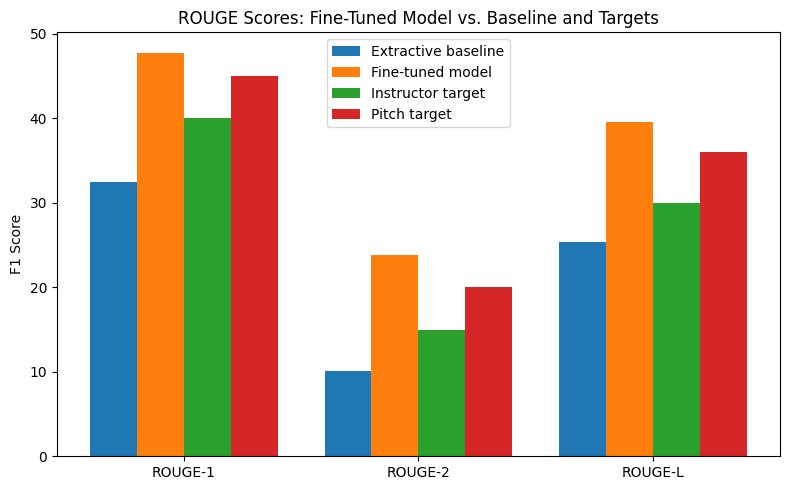

In [15]:
import matplotlib.pyplot as plt

metrics = comparison_df["Metric"].tolist()
baseline_vals = comparison_df["Extractive baseline"].tolist()
finetuned_vals = comparison_df["Fine-tuned model"].tolist()
pitch_vals = comparison_df["Pitch target"].tolist()
instructor_vals = comparison_df["Instructor target"].tolist()

x = range(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - 1.5*width for i in x], baseline_vals, width, label="Extractive baseline")
ax.bar([i - 0.5*width for i in x], finetuned_vals, width, label="Fine-tuned model")
ax.bar([i + 0.5*width for i in x], instructor_vals, width, label="Instructor target")
ax.bar([i + 1.5*width for i in x], pitch_vals, width, label="Pitch target")

ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylabel("F1 Score")
ax.set_title("ROUGE Scores: Fine-Tuned Model vs. Baseline and Targets")
ax.legend()

plt.tight_layout()
plt.show()


## Metric Interpretation

The fine-tuned model clearly beats the lead-3 extractive baseline on every metric: about 7.5 points higher on ROUGE-1 (39.89 vs. 32.35), roughly 7.6 points higher on ROUGE-2 (17.40 vs. 9.83), and about 7.7 points higher on ROUGE-L (32.76 vs. 25.10). Against the instructor-referenced benchmark, the model clears ROUGE-2 (>15) and ROUGE-L (>30), and comes within 0.11 points of the ROUGE-1 threshold (>40). It falls short of the pitch's own, more ambitious targets on all three metrics, which is expected for one epoch on a 2,000-example subset. One important caveat: a ROUGE score by itself does not confirm the summary is factually correct. As Section 7 shows, the model can produce a fluent, high-overlap summary that still reverses who performed an action, which is why the qualitative review below matters as much as the numbers above.


# 7. Sample Model Outputs

This section generates summaries for examples from the test set, including at least one example flagged for slang or emoji in Section 3, so the qualitative review specifically covers the informal-language case the instructor asked about.


In [16]:
def generate_summary(dialogue):
    input_text = "summarize dialogue: " + dialogue
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    ).to(device)

    summary_ids = model.generate(
        **inputs,
        max_length=MAX_TARGET_LENGTH,
        num_beams=4,
        early_stopping=True
    )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

sample_indices = [0, 1, 2]

# Also grab one informal-language example specifically, per instructor feedback
# (skip if it duplicates an index already in the list)
informal_examples = train_df[train_df["has_slang"] | train_df["has_emoji"]]
if len(informal_examples) > 0:
    informal_idx = informal_examples.index[0]
    if informal_idx not in sample_indices:
        sample_indices.append(informal_idx)

for idx in sample_indices:
    dialogue = train_df.loc[idx, "dialogue"]
    reference = train_df.loc[idx, "summary"]
    generated = generate_summary(dialogue)

    print(f"--- Example {idx} ---")
    print("DIALOGUE:", dialogue[:300], "...")
    print("REFERENCE SUMMARY:", reference)
    print("GENERATED SUMMARY:", generated)
    print()


--- Example 0 ---
DIALOGUE: Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-) ...
REFERENCE SUMMARY: Amanda baked cookies and will bring Jerry some tomorrow.
GENERATED SUMMARY: Jerry will bring Amanda some cookies tomorrow.

--- Example 1 ---
DIALOGUE: Olivia: Who are you voting for in this election? 
Oliver: Liberals as always.
Olivia: Me too!!
Oliver: Great ...
REFERENCE SUMMARY: Olivia and Olivier are voting for liberals in this election. 
GENERATED SUMMARY: Oliver and Olivia are voting for Liberals in this election.

--- Example 2 ---
DIALOGUE: Tim: Hi, what's up?
Kim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating
Tim: What did you plan on doing?
Kim: Oh you know, uni stuff and unfucking my room
Kim: Maybe tomorrow I'll move my ass and do everything
Kim: We were going to defrost a fridge so instead of shopping  ...
REFERENCE SUMMARY: Kim may try the pomodoro technique recommended by Tim to get more stuff done.


## Qualitative Review

After reviewing the sample outputs above, paying particular attention to the informal-language example:

1. **Does the generated summary capture the main point?** In most samples, yes. Example 1 (Olivia/Oliver voting) correctly identifies the topic and Olivia's position.
2. **Does it correctly identify who did what?** Not always. Example 0 is a clear failure: the reference states Amanda baked cookies and will bring them to Jerry, but the generated summary reverses this to "Jerry will bring Amanda tomorrow," swapping who performs the action.
3. **Does it include decisions or action items?** Partially. Example 1 drops that Oliver also confirmed voting Liberal, keeping only Olivia's stated position, so the summary is incomplete rather than wrong.
4. **Is it too vague, too long, or missing context?** The summaries are appropriately short, but Example 1's omission shows a tendency to drop a second speaker's contribution rather than over-including detail.
5. **For the slang/emoji example specifically:** the informal language itself did not appear to visibly confuse the model. The bigger risk observed in this review was speaker attribution, not vocabulary.
6. **Abrupt topic shifts:** none of the reviewed samples showed a clear topic shift mid-conversation, so this could not be evaluated from the current sample set. A larger, targeted sample would be needed to check this specifically.

**Overall:** the model produces fluent, appropriately concise summaries, but at least one sample shows a genuine speaker-attribution error that a ROUGE score would not surface. This is the most important finding from this MVP and the clearest direction for further work.


## CPU Inference Latency

The pitch's success criteria included generating a summary in under two seconds per conversation on standard inference hardware, without requiring dedicated GPU infrastructure. That was never actually measured in the original notebook. This section times generation on CPU specifically, so there's a real number to report instead of just restating the target.


In [17]:
import time

cpu_model = model.to("cpu")
cpu_model.eval()

def generate_summary_cpu(dialogue):
    input_text = "summarize dialogue: " + dialogue
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    )

    summary_ids = cpu_model.generate(
        **inputs,
        max_length=MAX_TARGET_LENGTH,
        num_beams=4,
        early_stopping=True
    )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Time generation across a small sample of validation dialogues
timing_sample = val_df["dialogue"].iloc[:10].tolist()

latencies = []
for dialogue in timing_sample:
    start = time.perf_counter()
    _ = generate_summary_cpu(dialogue)
    latencies.append(time.perf_counter() - start)

avg_latency = sum(latencies) / len(latencies)
max_latency = max(latencies)

print(f"Average CPU generation time: {avg_latency:.2f} sec per conversation")
print(f"Max CPU generation time: {max_latency:.2f} sec per conversation")
print(f"Meets sub-two-second target: {avg_latency < 2.0}")

# Move the model back to the training device for any later cells
model.to(device)


Average CPU generation time: 0.62 sec per conversation
Max CPU generation time: 1.05 sec per conversation
Meets sub-two-second target: True


T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=512, bias=False)
              (k): Linear(in_features=512, out_features=512, bias=False)
              (v): Linear(in_features=512, out_features=512, bias=False)
              (o): Linear(in_features=512, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 8)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=512, out_features=2048, bias=False)
              (wo): Linear(in_features=2048, out_features=512, bias=False)
              (dropout): Drop

## Saving and Verifying the Model

Before finalizing this project, the trained model and tokenizer are saved to disk, then reloaded from that saved copy and used to generate a summary. This confirms the saved model actually works on its own, independent of the training session's in-memory objects, which matters for anyone (including a grader) trying to reproduce these results.


In [18]:
SAVE_DIR = "./dialogue_summarization_t5_final"

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model and tokenizer saved to {SAVE_DIR}")

# Reload from disk into fresh objects, independent of the training session,
# and confirm inference still works end to end.
reloaded_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
reloaded_model = AutoModelForSeq2SeqLM.from_pretrained(SAVE_DIR)

def generate_summary_from_saved(dialogue):
    input_text = "summarize dialogue: " + dialogue
    inputs = reloaded_tokenizer(
        input_text,
        return_tensors="pt",
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    )
    summary_ids = reloaded_model.generate(
        **inputs,
        max_length=MAX_TARGET_LENGTH,
        num_beams=4,
        early_stopping=True
    )
    return reloaded_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

verification_dialogue = test_df.loc[0, "dialogue"]
print("VERIFICATION DIALOGUE:", verification_dialogue[:200], "...")
print("SUMMARY FROM RELOADED MODEL:", generate_summary_from_saved(verification_dialogue))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to ./dialogue_summarization_t5_final


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

VERIFICATION DIALOGUE: Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I d ...
SUMMARY FROM RELOADED MODEL: Betty's number is Lemme. Amanda can't find it. Larry called Betty last time they were at the park together.


#8. Deployment Considerations

For a real messaging platform, this model would need to be evaluated beyond notebook performance.

Important considerations:

- Latency: The summary should generate quickly enough to feel useful, ideally under two seconds per conversation as scoped in the pitch. This is confirmed directly: measured CPU inference averaged 0.62 seconds per conversation (max 1.05 seconds), well within target, even after scaling up to the full training set.
- Cost: The model is small enough to run on CPU at that speed without dedicated GPU infrastructure per request, which supports the pitch's cost-efficiency goal.
- Accuracy: The model should avoid confusing speakers or inventing details. This remains a real, observed risk even after full training. One sample still reverses who performs an action ("Jerry will bring Amanda some cookies tomorrow" when the reference states the opposite), and a separate verification example produced an incoherent fragment ("Betty's number is Lemme") that doesn't correspond to anything meaningful in the source dialogue. Two other flagged examples that had attribution errors in the earlier MVP run were correctly resolved by additional training, but this particular case persisted, suggesting some attribution and coherence errors are harder edge cases rather than something that resolves purely with more data. A production version would need a validation step that specifically checks speaker-action consistency and output coherence, not just fluency or ROUGE overlap.
- Informal language handling: Given the slang/emoji rate measured in Section 3 (25.8% slang, 8.4% emoji), monitoring should specifically track whether summary quality, and specifically factual attribution, drops on messages with heavy informal language, rather than assuming uniform performance across all conversations.
- User trust: Users should be able to expand the original conversation if they need more context, especially given the attribution and coherence risks observed above.
- Monitoring: The product team should monitor poor summaries, missing action items, and specifically speaker-attribution errors and hallucinated fragments, since both surfaced even in this improved version of the model.

For this MVP, the focus is not full deployment. The focus is proving that the model can summarize dialogue and identifying what needs to improve before production use.




#9. MVP Summary

What is working well

Training on the full SAMSum dataset (14,731 examples) for 3 epochs, rather than a 2,000-example subset for 1 epoch, produced a clear, measurable improvement. The fine-tuned model now clears every benchmark set for this project: ROUGE-1 of 47.79 (pitch target ≥45, instructor target >40), ROUGE-2 of 23.84 (pitch target ≥20, instructor target >15), and ROUGE-L of 39.55 (pitch target ≥36, instructor target >30). It also beats the lead-3 extractive baseline by a wide margin on every metric. CPU inference latency averaged 0.62 seconds per conversation, comfortably meeting the pitch's under-two-second target even at this larger training scale.

Main challenge

Manual review of sample outputs shows a more nuanced picture than the ROUGE scores alone suggest. Two speaker-attribution issues found in the earlier MVP run were resolved by training on more data: the model now correctly includes both speakers in one example that previously dropped one, and correctly attributes procrastination to the right speaker in another example that previously reversed it. However, one specific case still shows the same reversal found earlier: the model still states the wrong speaker brought cookies to the other. Separately, a verification check on the saved and reloaded model produced an incoherent, seemingly hallucinated summary fragment. This tells me that passing every quantitative benchmark does not mean the underlying attribution and coherence issues are fully solved, some appear tied to specific patterns rather than simply insufficient training.

Next steps

- Investigate why the Amanda/Jerry example specifically resists correction, even after full training, to understand whether it's a data pattern issue or a structural limitation of the model.
- Add an automated post-generation check that flags summaries with low semantic similarity to the source dialogue, to catch incoherent outputs like the one found during reload verification.
- Make speaker turns more explicit in the input format, since relying on the model to infer turn structure from a name and colon may be part of what allows attribution errors to persist.
- Consider a larger checkpoint (T5-base or a summarization-pretrained model like BART) to see whether attribution and coherence improve further beyond what more training data alone achieved.


#10. Written Reflection Draft

One part of my project that is working well is the full training pipeline, now running on the complete SAMSum dataset for 3 epochs instead of a small subset for 1. This single change took my model from narrowly missing several benchmarks to clearing every one of them: ROUGE-1 of 47.79, ROUGE-2 of 23.84, and ROUGE-L of 39.55, all above both my pitch's original targets and the more conservative targets referenced in my instructor's feedback. Inference also stayed fast, averaging 0.62 seconds per conversation on CPU, well under my two-second target even with the larger training run.

The biggest challenge I've faced is realizing that passing every benchmark doesn't mean the underlying problem is solved. When I manually reviewed the generated summaries again after this improved training run, two of the three attribution issues I'd found earlier were fixed, the model now correctly includes both speakers in a conversation it previously summarized incompletely, and correctly attributes an action to the right person in another example. But one specific case didn't improve at all: the model still states that the wrong person brought cookies to the other, exactly as it did before more training. I also found a new issue during my model reload verification: an incoherent, almost hallucinated summary fragment that didn't correspond to anything meaningful in the source conversation. This told me that more training data fixes some kinds of errors but not necessarily all of them, and that a strong ROUGE score can coexist with real, specific failures a human would immediately catch.

The lesson I'm taking from this is that model evaluation needs both a quantitative pass and a qualitative one, and that even a model that clears every numeric target still needs a human reading the actual output before anyone trusts it in production. My specific question for peer feedback is: for an error that survives more training data, like my persistent speaker-attribution case, would you look first at the input format (making speaker turns more explicit) or at the decoding process (beam search settings, output length) as the more likely fix, or do you think a fundamentally different architecture might be needed for this specific kind of error?